In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import parameters as p
import auxiliary_funcs as af 
import collisions_vec as col
import monte_carlo_vec as mc

# PURPOSE: Test pitch-angle scattering. See if correction means correct isotropization.

In [3]:
# effective drift and diffusion coefficient for pitch-angle scattering
def Asim_xi(v_current, reg=False): 
    x, xi = v_current[0], v_current[1] 
    drift = - 2 * xi / x**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x))

    if reg: 
        reg_drift = - xi / x**2 * (4 * p.ZPERP / np.sqrt(np.pi) * af.WPERPB_MONO - 2 / (3 * np.sqrt(np.pi)) * af.WB_CUBE)
        return np.where(x < 1e-7, reg_drift, drift)
    else:
        return drift


def D_xixi(v_current, reg=True): 
    x, xi = v_current[0], v_current[1] 
    coefficient = 1 / x**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x)) * (1-xi**2)

    if reg: 
        reg_coefficient = 1 / x**2 * (2 * p.ZPERP / np.sqrt(np.pi) * af.WPERPB_MONO - 1 / (3 * np.sqrt(np.pi)) * af.WB_CUBE)
        return np.where(x < 1e-6, reg_coefficient, coefficient)
    else: 
        return coefficient

In [ ]:
xvals = np.logspace(-12, -1, 1000)
arr = np.vstack([xvals, -np.ones_like(xvals)/2])

plt.figure(dpi=300)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(1e-12,1e-1)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$A^{\xi}_\text{sim}$', fontsize=12)
plt.plot(xvals, Asim_xi(arr, reg=False), color='blueviolet', label='not regularized', linewidth=2)
plt.plot(xvals, Asim_xi(arr, reg=True), color='darkorange', label='regularized', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle=':', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=10)
plt.show()

plt.figure(dpi=300)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(1e-12,1e-1)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$D^{\xi\xi}$', fontsize=12)
plt.plot(xvals, D_xixi(arr, reg=False), color='blueviolet', label='not regularized', linewidth=2)
plt.plot(xvals, D_xixi(arr, reg=True), color='darkorange', label='regularized', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle=':', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=10)
plt.show()

In [5]:
# functions for running Monte-Carlo code
def singlestep_mc(v_current, Ds_func, As_func, dt):
    Ds_loc = Ds_func(v_current)
    As_loc = As_func(v_current)

    x_current, xi_current = v_current

    dv_D_xi = np.random.normal(loc=xi_current, scale=np.sqrt(2*Ds_loc*dt)) - xi_current
    dv_A_xi = As_loc * dt

    xi_new = xi_current + dv_D_xi + dv_A_xi
    while xi_new < -1 or xi_new > 1: # bounce by reflection
        if xi_new < -1:
            xi_new = -2 - xi_new   
        elif xi_new > 1:
            xi_new = 2 - xi_new

    v_new = [x_current, xi_new]
    return v_new 

def multistep_mc(v_initial, numsteps, Ds_func, As_func, dt): 
    v_current = v_initial.copy()
    v_store = []
    v_store.append(v_current)

    for i in tqdm(range(numsteps), desc=f"MC steps x = {v_initial[0]}"):
        v_new = singlestep_mc(v_current, Ds_func, As_func, dt)
        # print(f'step {i} v = {v_new}')
        v_store.append(v_new)
        v_current = v_new

    return np.array(v_store)


In [8]:
DT = 1e-1
V_INITIAL = [1, 0]
NUMSTEPS = int(1e8)
x_initial, xi_initial = V_INITIAL
print(np.sqrt(2*D_xixi(V_INITIAL)*DT))
print(1/np.sqrt(2*D_xixi(V_INITIAL)*DT))

print(np.sqrt(2*col.D_xixi(V_INITIAL)*DT)) # testing new vectorized code
print(1/np.sqrt(2*col.D_xixi(V_INITIAL)*DT))

0.057693833444875976
17.332874941573397
0.057693833444875976
17.332874941573397


In [ ]:
# simulate with geometrical factor
result_geom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xixi, As_func=Asim_xi, dt=DT)

# simulate without geometrical correction
result_nogeom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xixi, As_func=lambda x:0, dt=DT)

MC steps x = 1: 100%|██████████| 100000000/100000000 [39:00<00:00, 42722.63it/s] 


dt=0.1 numsteps=100000000


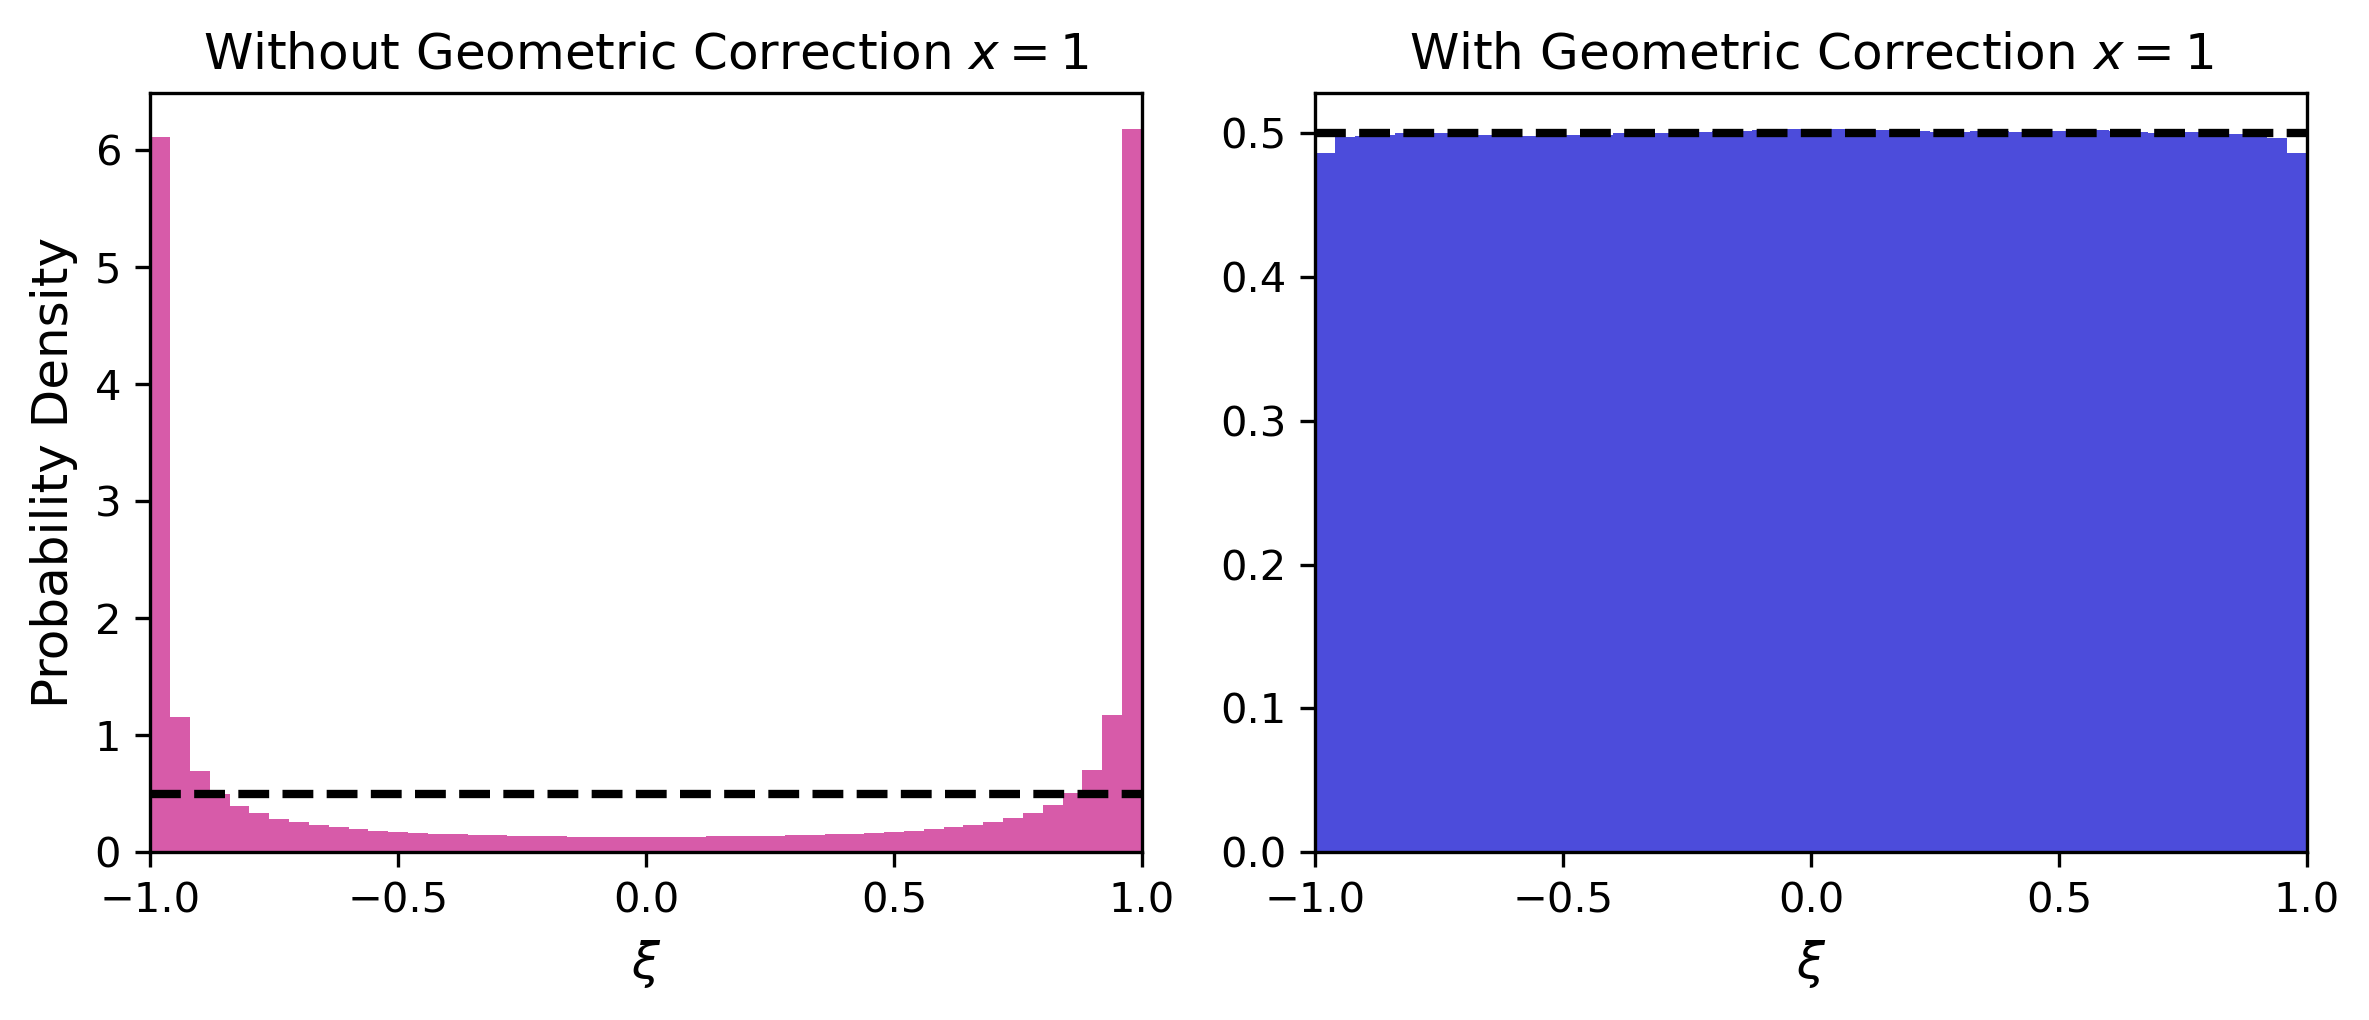

In [45]:
# Histograms - Try low x, try high x.
print(f'dt={DT} numsteps={NUMSTEPS}')

xi_vals_nogeom = result_nogeom[:, 1]
xi_vals_geom = result_geom[:, 1]

plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(xi_vals_nogeom, bins=50, density=True, color='mediumvioletred', alpha=0.7) # CHANGE BACK TO NOGEOM
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(r'$\xi$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(-1,1)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2)
plt.title(rf'Without Geometric Correction $x={x_initial}$', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(xi_vals_geom, bins=50, density=True, color='mediumblue', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(r'$\xi$', fontsize=12)
plt.xlim(-1,1)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2)
plt.title(rf'With Geometric Correction $x={x_initial}$', fontsize=12)

plt.tight_layout()
plt.show()



In [46]:
DT = 1e-4
V_INITIAL = [0.1, 0]
NUMSTEPS = int(1e4)
x_initial, xi_initial = V_INITIAL
print(np.sqrt(2*D_xixi(V_INITIAL)*DT))
print(1/np.sqrt(2*D_xixi(V_INITIAL)*DT))

0.04575381709264092
21.856099961566724


In [47]:
result_geom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xixi, As_func=Asim_xi, dt=DT)
result_nogeom = multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, Ds_func=D_xixi, As_func=lambda x:0, dt=DT)

MC steps x = 0.1: 100%|██████████| 100000000/100000000 [25:06<00:00, 66382.11it/s] 


dt=0.0001 numsteps=100000000


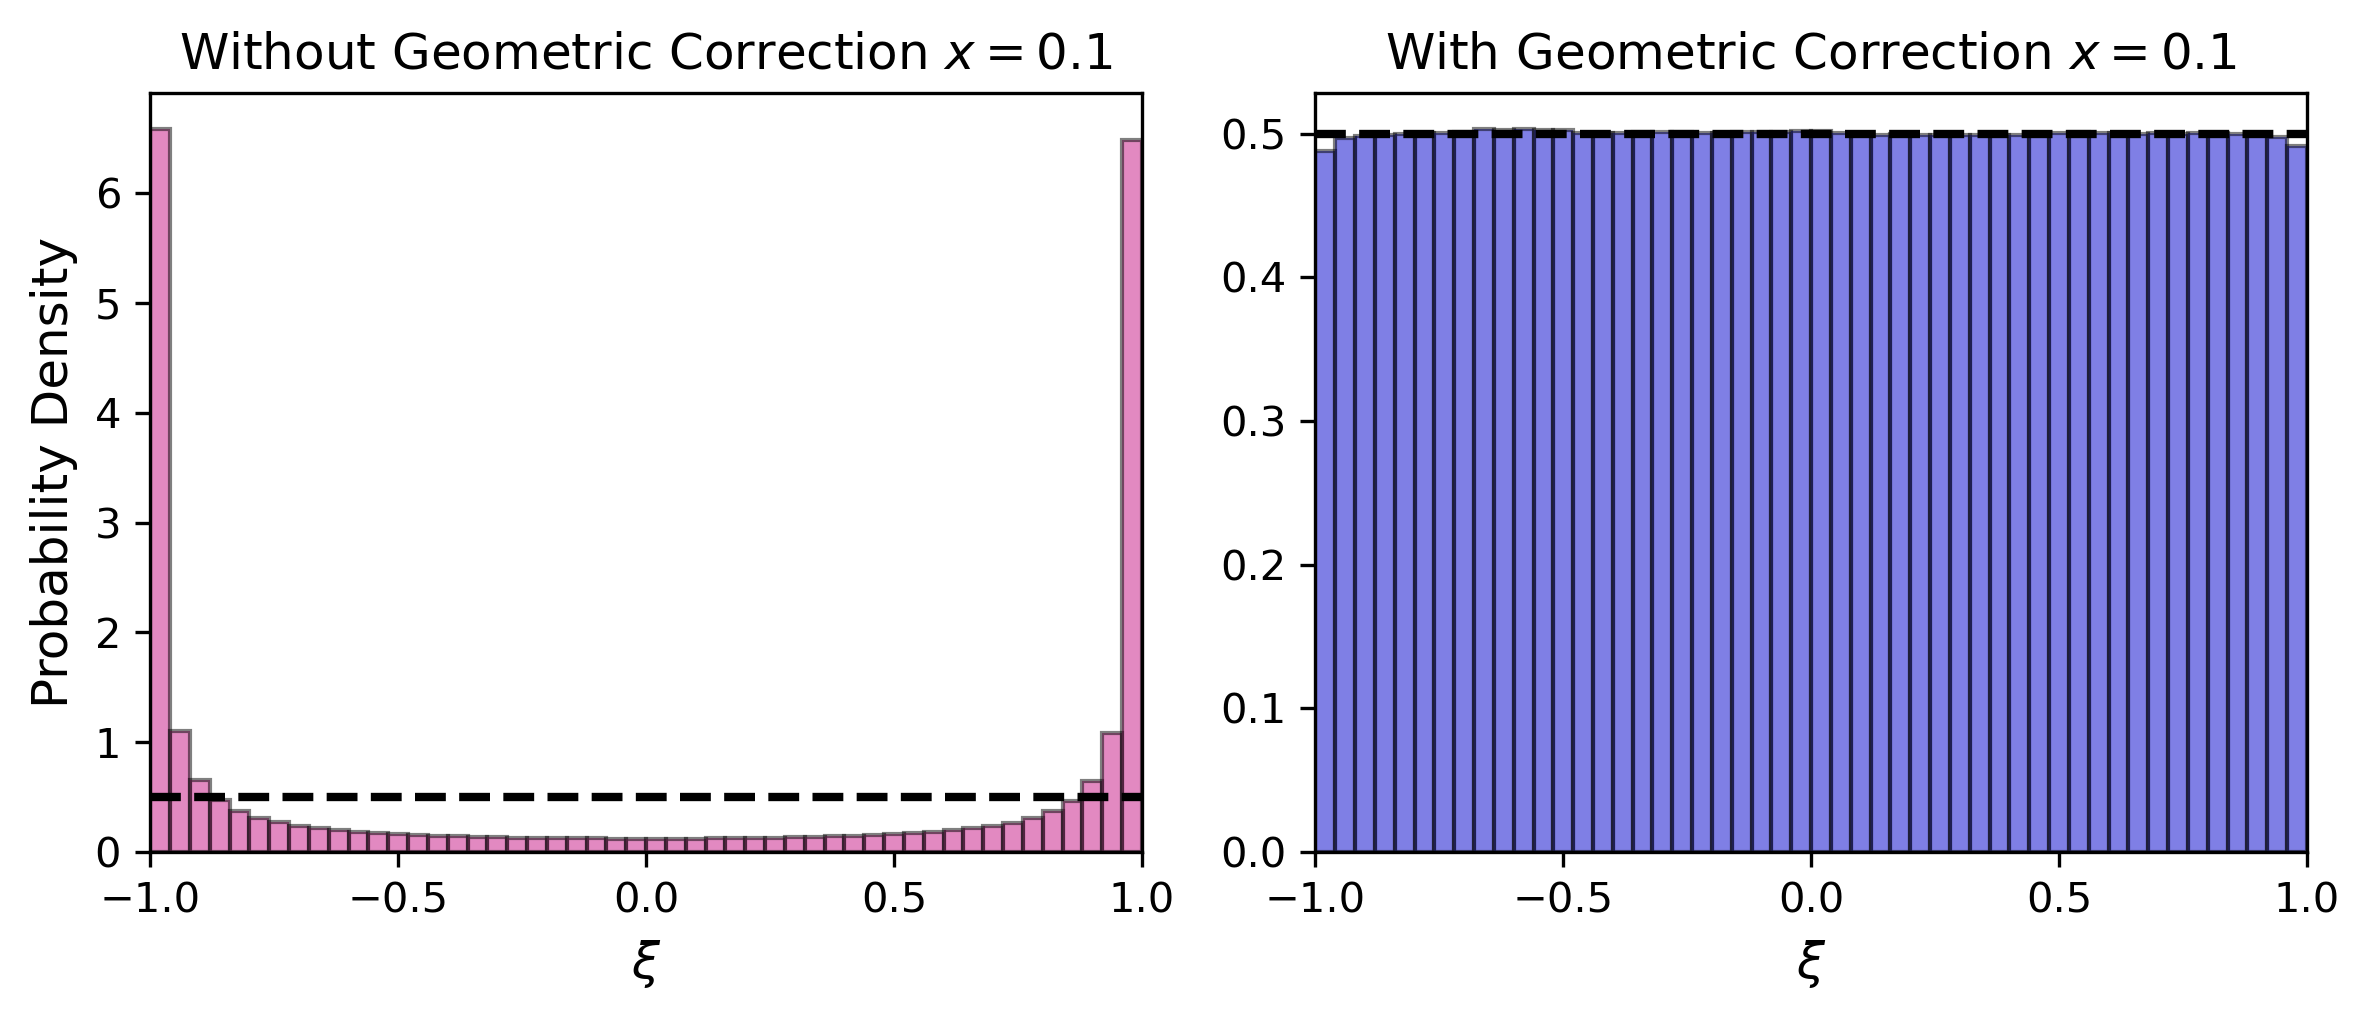

In [49]:
print(f'dt={DT} numsteps={NUMSTEPS}')

xi_vals_nogeom = result_nogeom[:, 1]
xi_vals_geom = result_geom[:, 1]

plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(xi_vals_nogeom, bins=50, density=True, color='mediumvioletred', alpha=0.5, edgecolor='black')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(r'$\xi$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(-1,1)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2)
plt.title(rf'Without Geometric Correction $x={x_initial}$', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(xi_vals_geom, bins=50, density=True, color='mediumblue', alpha=0.5, edgecolor='black')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(r'$\xi$', fontsize=12)
plt.xlim(-1,1)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2)
plt.title(rf'With Geometric Correction $x={x_initial}$', fontsize=12)

plt.tight_layout()
plt.show()
